# FSM Data Analysis

## Import libraries & Load the data

In [ ]:
import pandas as pd
from google.colab import drive
import matplotlib.pyplot as plt

In [ ]:
drive.mount('/content/drive', force_remount=False)

Mounted at /content/drive


In [ ]:
FS_Dataset = pd.read_csv('/content/drive/MyDrive/FS_Dataset/Cleaned_Flood_Data.csv')

In [ ]:
df = FS_Dataset.copy()

## Initial Overview of the Dataset

In [ ]:
# Dataset structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 280 entries, 0 to 279
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   f_nf                 280 non-null    int64  
 1   aspect               280 non-null    float64
 2   dem                  280 non-null    float64
 3   distance_from_river  280 non-null    float64
 4   flow_accumulation    280 non-null    int64  
 5   land_use             280 non-null    int64  
 6   lithology            280 non-null    int64  
 7   plan_curvature       280 non-null    float64
 8   profile_curvature    280 non-null    float64
 9   rainfall             280 non-null    float64
 10  slope                280 non-null    float64
 11  soil                 280 non-null    int64  
 12  spi                  280 non-null    float64
 13  tpi                  280 non-null    float64
 14  tri                  280 non-null    float64
 15  twi                  280 non-null    flo

In [ ]:
# List of categorical columns
categorical_cols = ['f_nf', 'land_use', 'lithology', 'soil']

# Convert to category dtype
for col in categorical_cols:
    df[col] = df[col].astype('category')

# Check the result
df[categorical_cols].dtypes

,0
f_nf,category
land_use,category
lithology,category
soil,category


In [ ]:
# Summary statistics for numeric columns
df.describe().T

,count,mean,std,min,25%,50%,75%,max
aspect,280.0,185.465595,109.638944,1.229660,83.217623,195.106499,282.908745,359.299011
dem,280.0,83.696795,85.917712,5.282580,16.863225,44.784451,141.096500,377.085999
distance_from_river,280.0,903.789147,661.356731,0.000000,387.200012,798.232971,1355.199951,3296.889893
flow_accumulation,280.0,329.753571,3310.984160,0.000000,0.000000,1.000000,5.000000,38581.000000
plan_curvature,280.0,0.030858,0.277068,-1.049510,-0.112701,0.006488,0.176196,0.846791
profile_curvature,280.0,-0.010118,0.266485,-0.966904,-0.140855,-0.002128,0.131482,1.717200
rainfall,280.0,50.205980,2.010755,45.845699,48.849801,50.374901,51.563525,54.413399
slope,280.0,5.356730,6.440318,0.000000,0.848662,2.639030,6.991708,31.481701
spi,280.0,370.485352,3450.329292,0.000000,0.000000,1.718150,10.791075,48903.398438
tpi,280.0,2.650069,12.474992,-31.533899,-2.866132,-0.098498,4.228030,59.337200


###  **Analysis**
\
###  **Topographic Variables**

| Feature              | Observations |
|----------------------|--------------|
| **aspect**           | Mean: ~185°, values range from ~1° to ~359°. Almost full circle – this makes sense as aspect is measured in degrees. |
| **dem**              | Elevation ranges from ~5m to ~377m. Indicates variation in terrain height across the study area. |
| **slope**            | Ranges from 0 to 31°, average around 5.36°. Some steep slopes present, could influence runoff. |
| **spi / tpi / tri**  | These terrain indices (Stream Power Index, Topographic Position Index, Terrain Ruggedness Index) show wide ranges, especially `spi` and `tpi`, suggesting notable variation in landscape features. |
| **curvatures**       | (`plan_curvature`, `profile_curvature`) are centered around 0 (as expected), but have both negative and positive values, indicating convex/concave forms. |

\\
###  **Hydrological Variables**

| Feature               | Observations |
|-----------------------|--------------|
| **distance_from_river** | Ranges from ~387 to ~3269 meters. Wide variation—can be very important for flood likelihood. |
| **flow_accumulation**  | **Highly skewed**: min = 0, max = 38,581! Median is 1. Suggests heavy right skew. A few locations dominate this variable. Might benefit from **log transformation**. |
| **rainfall**           | Min = 45.8 mm, Max = 54.4 mm — low variance.|

\\
###  **Other Indices**

| Feature       | Observations |
|---------------|--------------|
| **twi**       | Topographic Wetness Index ranges from ~1.18 to ~18.92, with a mean around 7.83. This is usually a strong flood predictor. |
| **tri**       | Ranges from 0 to 0.76, suggesting mostly smooth terrain with a few rugged spots. |
| **tpi**       | Wide range from -51 to +59. Positive indicates ridges, negative indicates valleys. Potentially very helpful in modeling. |

\\

⚠️ Points to Act On

- flow_accumulation, spi, and tpi are highly skewed, as seen from the big gap between mean and median. Consider applying log transformation or scaling to reduce skew and improve model training.



## Target Variable Distribution

Check class balance of f_nf (Flood = 1, No flood = 0)

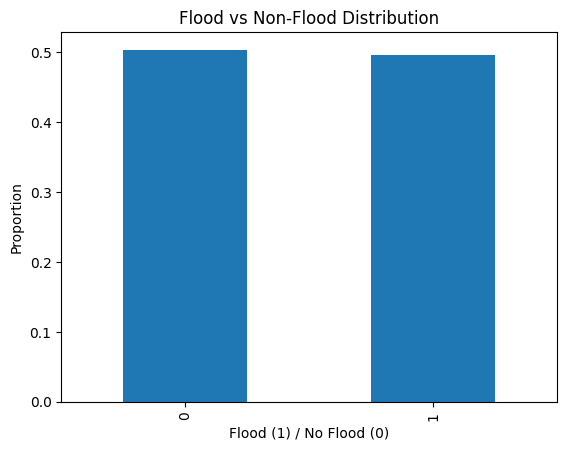

In [ ]:
# Value counts
df['f_nf'].value_counts(normalize=True).plot(kind='bar', title='Flood vs Non-Flood Distribution')
plt.xlabel('Flood (1) / No Flood (0)')
plt.ylabel('Proportion')
plt.show()

In [ ]:
# Get value counts and percentages
class_dist = df['f_nf'].value_counts(normalize=True) * 100

# Print percentages
for cls, pct in class_dist.items():
    label = "Flood (1)" if cls == 1 else "No Flood (0)"
    print(f"{label}: {pct:.2f}%")

No Flood (0): 50.36%
Flood (1): 49.64%


This confirms the dataset is perfectly balanced

## Univariate Analysis

Visualize distributions of each numerical feature

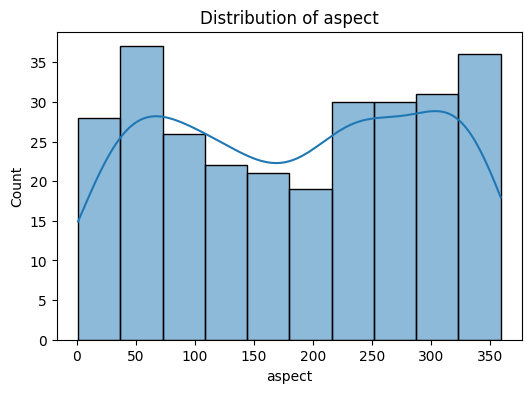

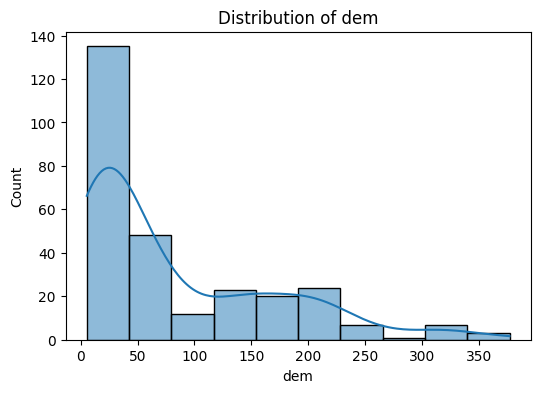

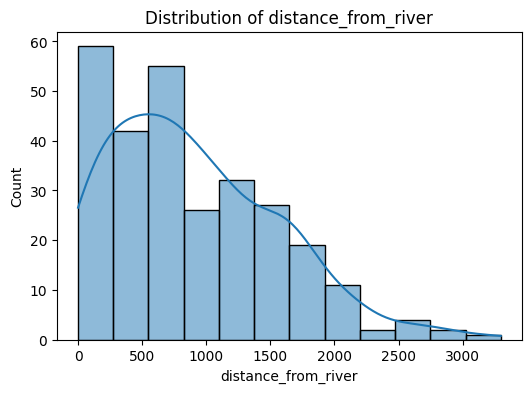

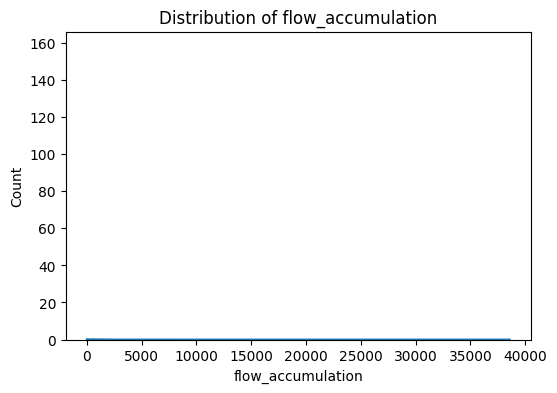

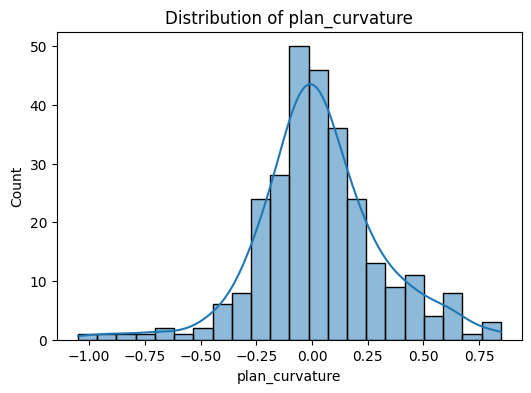

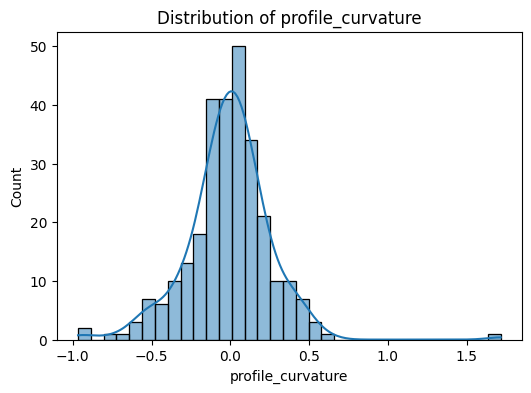

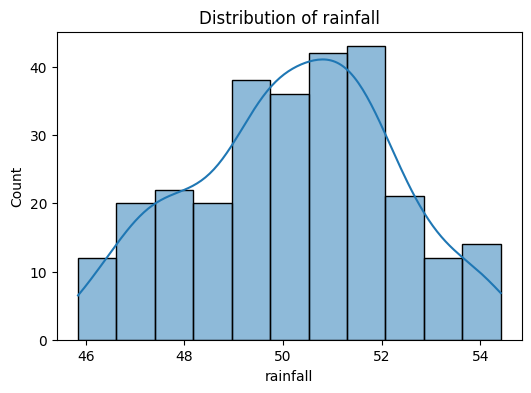

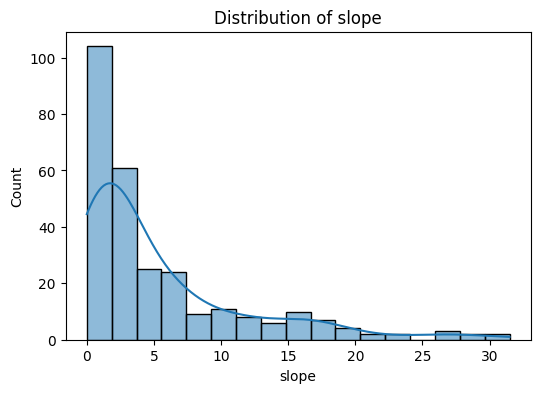

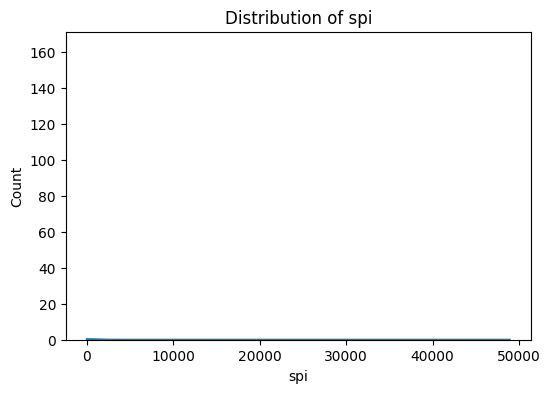

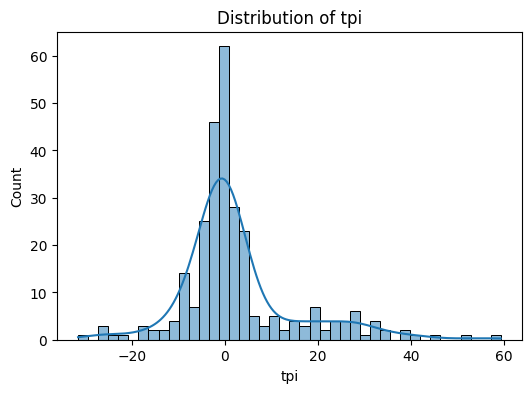

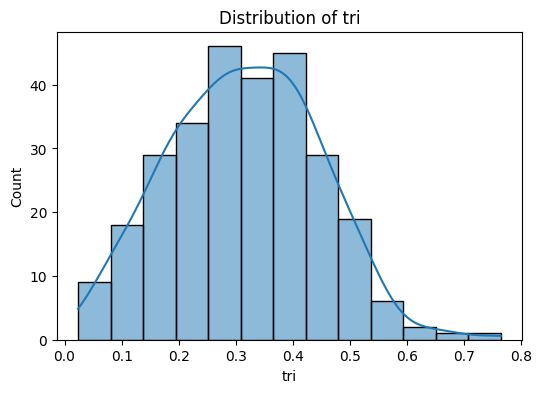

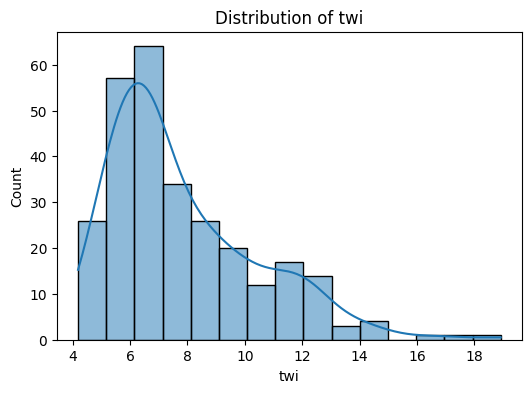

In [ ]:
# Histograms for all numerical features
num_cols = df.select_dtypes(include='number').columns.tolist()

# Plot histograms
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

### **Analysis**
\

| Feature                | Distribution Shape     | Interpretation |
|------------------------|------------------------|----------------|
| **aspect**             | Fairly uniform         | All slope directions are represented; no directional bias. |
| **dem**                | Right-skewed           | Majority of locations are low elevation; a few high points. Consider log transformation. |
| **distance_from_river**| Right-skewed           | Many points are close to rivers. Typical for flood studies. |
| **flow_accumulation**  | **Extremely skewed**   | Almost all values are very small; a few large outliers dominate. Apply log transformation. |
| **plan_curvature**     | Normal-like            | Symmetric, centered around 0. Well-behaved feature. |
| **profile_curvature**  | Normal-like            | Similar to plan curvature; centered near zero. No issues. |
| **rainfall**           | Slightly bell-shaped   | Centered around 50 mm; very low variance. Might not be very informative alone. |
| **slope**              | Right-skewed           | Majority of slopes are gentle; very steep slopes are rare. |
| **spi**                | **Extremely skewed**   | Similar to flow accumulation. Apply log transformation before modeling. |
| **tpi**                | Bell-shaped            | Centered around 0, useful for identifying ridges and valleys. |
| **tri**                | Bell-shaped            | Mostly smooth terrain; only a few rugged zones. Suitable as-is. |
| **twi**                | Right-skewed           | Indicates many areas with low wetness, and few with high. Consider log or standard scaling. |

---
\
###  Key Notes

-  **Highly skewed features**:
  - `flow_accumulation`, `spi`, `twi`, `dem`, and `distance_from_river`
  - These are great candidates for **log transformation** or **power transforms** to improve model learning.

-  **Low variance**:
  - `rainfall` may not contribute strongly to classification unless interacted with other variables.

-  **Cyclic variable**:
  - `aspect` is circular (0° and 360° are the same direction). For some models, use `sin(aspect)` and `cos(aspect)` instead of raw value.

-  **Well-distributed / Normal-like**:
  - `plan_curvature`, `profile_curvature`, `tpi`, `tri` are already well-shaped and do not need transformation.



## Correlation Heatmap

Check correlations between features and the target

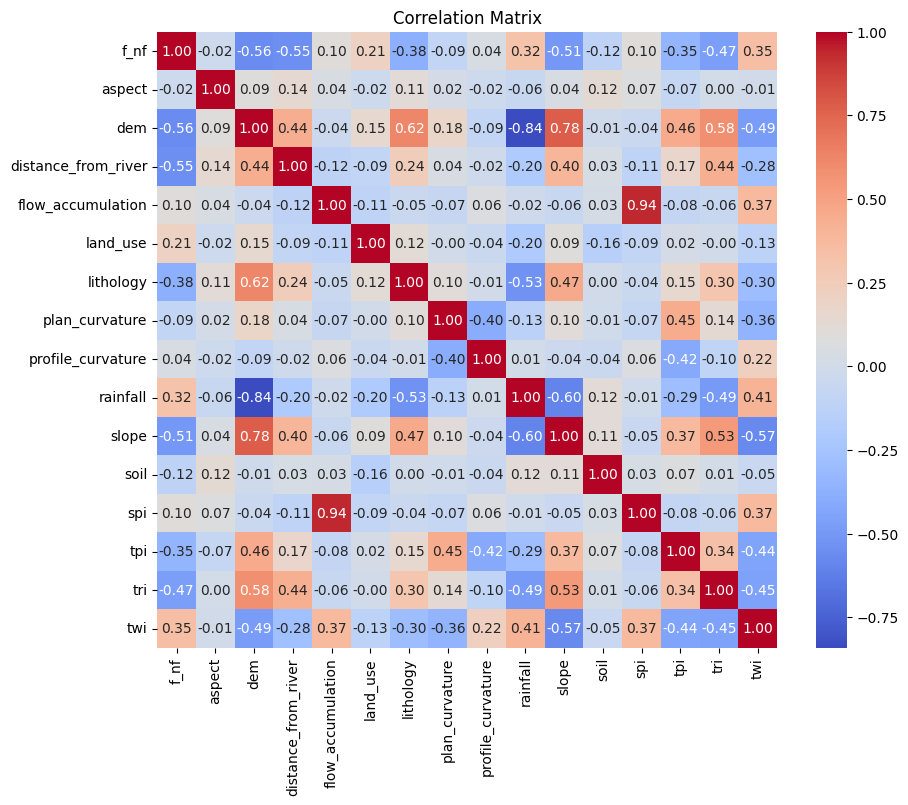

In [ ]:
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

### **Analysis**

### 🔗 Step 5: Correlation Analysis

The correlation matrix reveals key relationships between features and with the target variable `f_nf`.

---

#### 📌 **Top Features Correlated with Flood Susceptibility (`f_nf`)**

| Feature              | Correlation with `f_nf` | Interpretation |
|----------------------|--------------------------|----------------|
| `dem`                | **−0.56**                | Lower elevation is strongly associated with flood-prone areas. |
| `distance_from_river`| −0.55                    | Closer proximity to rivers increases flood likelihood. |
| `tri`                | −0.47                    | Smoother terrains (lower TRI) are more flood-susceptible. |
| `lithology`          | −0.38                    | Certain rock types may affect infiltration/runoff. |
| `tpi`                | −0.35                    | Lower TPI (valleys) are more prone to flooding. |
| `twi`                | **+0.35**                | High wetness index correlates with flood-prone zones. |
| `rainfall`           | +0.32                    | Higher rainfall increases flood likelihood. |

✅ **Insight**: `dem`, `distance_from_river`, `twi`, and `tri` appear to be among the strongest predictors of flood presence.

---

#### 🔁 **Highly Correlated Feature Pairs (Potential Redundancy)**

| Feature Pair               | Correlation | Action |
|----------------------------|-------------|--------|
| `flow_accumulation` & `spi`| **+0.94**   | Redundant — choose one or use dimensionality reduction. |
| `slope` & `dem`            | +0.78       | Steeper slopes are found in elevated areas — expected. |
| `dem` & `rainfall`         | **−0.84**   | Suggests rainfall is heavier in lower areas — interesting pattern. |
| `lithology` & `dem`        | +0.62       | Lithological variation may follow elevation. |

⚠️ Consider removing or combining highly correlated pairs in ML to avoid multicollinearity.

---

### ✅ Summary

- **Important predictors**: `dem`, `distance_from_river`, `twi`, `tri`
- **Multicollinearity warning**: `flow_accumulation` and `spi` (ρ = 0.94)
- **No correlation**: `aspect`, `soil`, and curvatures have weak correlation with `f_nf`.



## Categorical Feature Analysis

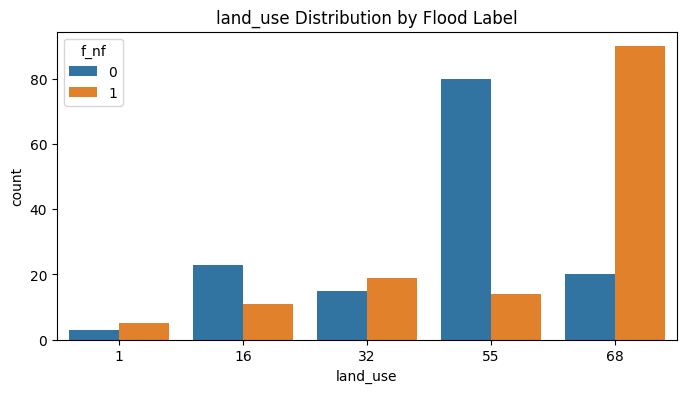

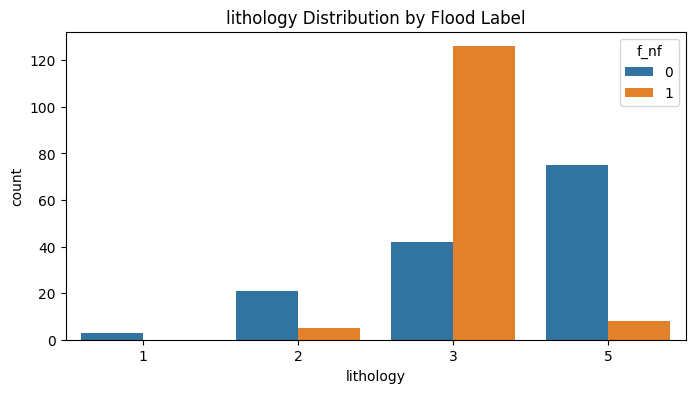

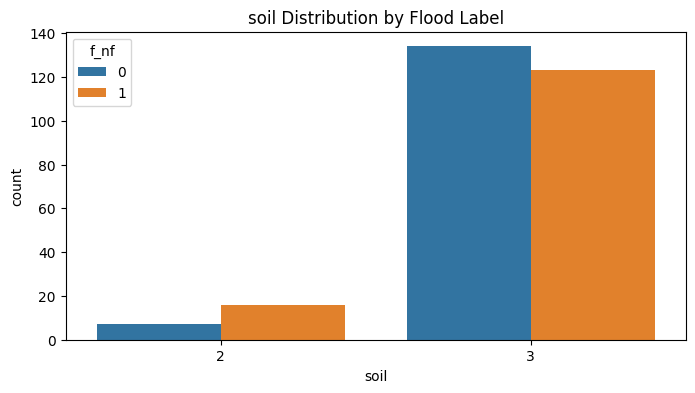

In [ ]:
categorical_cols = ['land_use', 'lithology', 'soil']

for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue='f_nf')
    plt.title(f'{col} Distribution by Flood Label')
    plt.show()

### **Analysis**
\


####  `land_use` vs `f_nf`

| Category | Observation |
|----------|-------------|
| 55       | Predominantly associated with **non-flood** areas. |
| 68       | Strongly associated with **flood** areas — highest flood count. |
| 16, 32   | Appear fairly mixed between flood and non-flood zones. |
| 1        | Least frequent; low but balanced presence. |

**Insight**: Certain land uses (e.g., code 68) are strongly flood-prone, possibly due to urban expansion or low-lying land types.

---
\
####  `lithology` vs `f_nf`

| Category | Observation |
|----------|-------------|
| 3        | Dominates **flood-prone** zones. |
| 5        | More common in **non-flood** zones. |
| 2        | Slight skew toward non-flood. |
| 1        | Rare category overall. |

**Insight**: Lithological type 3 likely contributes to reduced infiltration or increased runoff, increasing flood risk.

---
\
####  `soil` vs `f_nf`

| Category | Observation |
|----------|-------------|
| 3        | Majority class for both flood and non-flood; almost balanced. |
| 2        | Minor category, slightly more common in **flood-prone** areas. |

**Insight**: While not strongly discriminative, **soil type 2** may slightly correlate with flooding. Could be more useful when combined with other factors (e.g., slope or rainfall).

---
\
###  Summary

- **land_use** and **lithology** show **clear patterns** distinguishing flood from non-flood zones.
- **soil** has low variation, but soil type 2 shows a **minor flood tendency**.
- These categorical features will benefit from **encoding** (e.g., one-hot, label encoding) before feeding into machine learning models.



## Pairplot

To visualize relationships

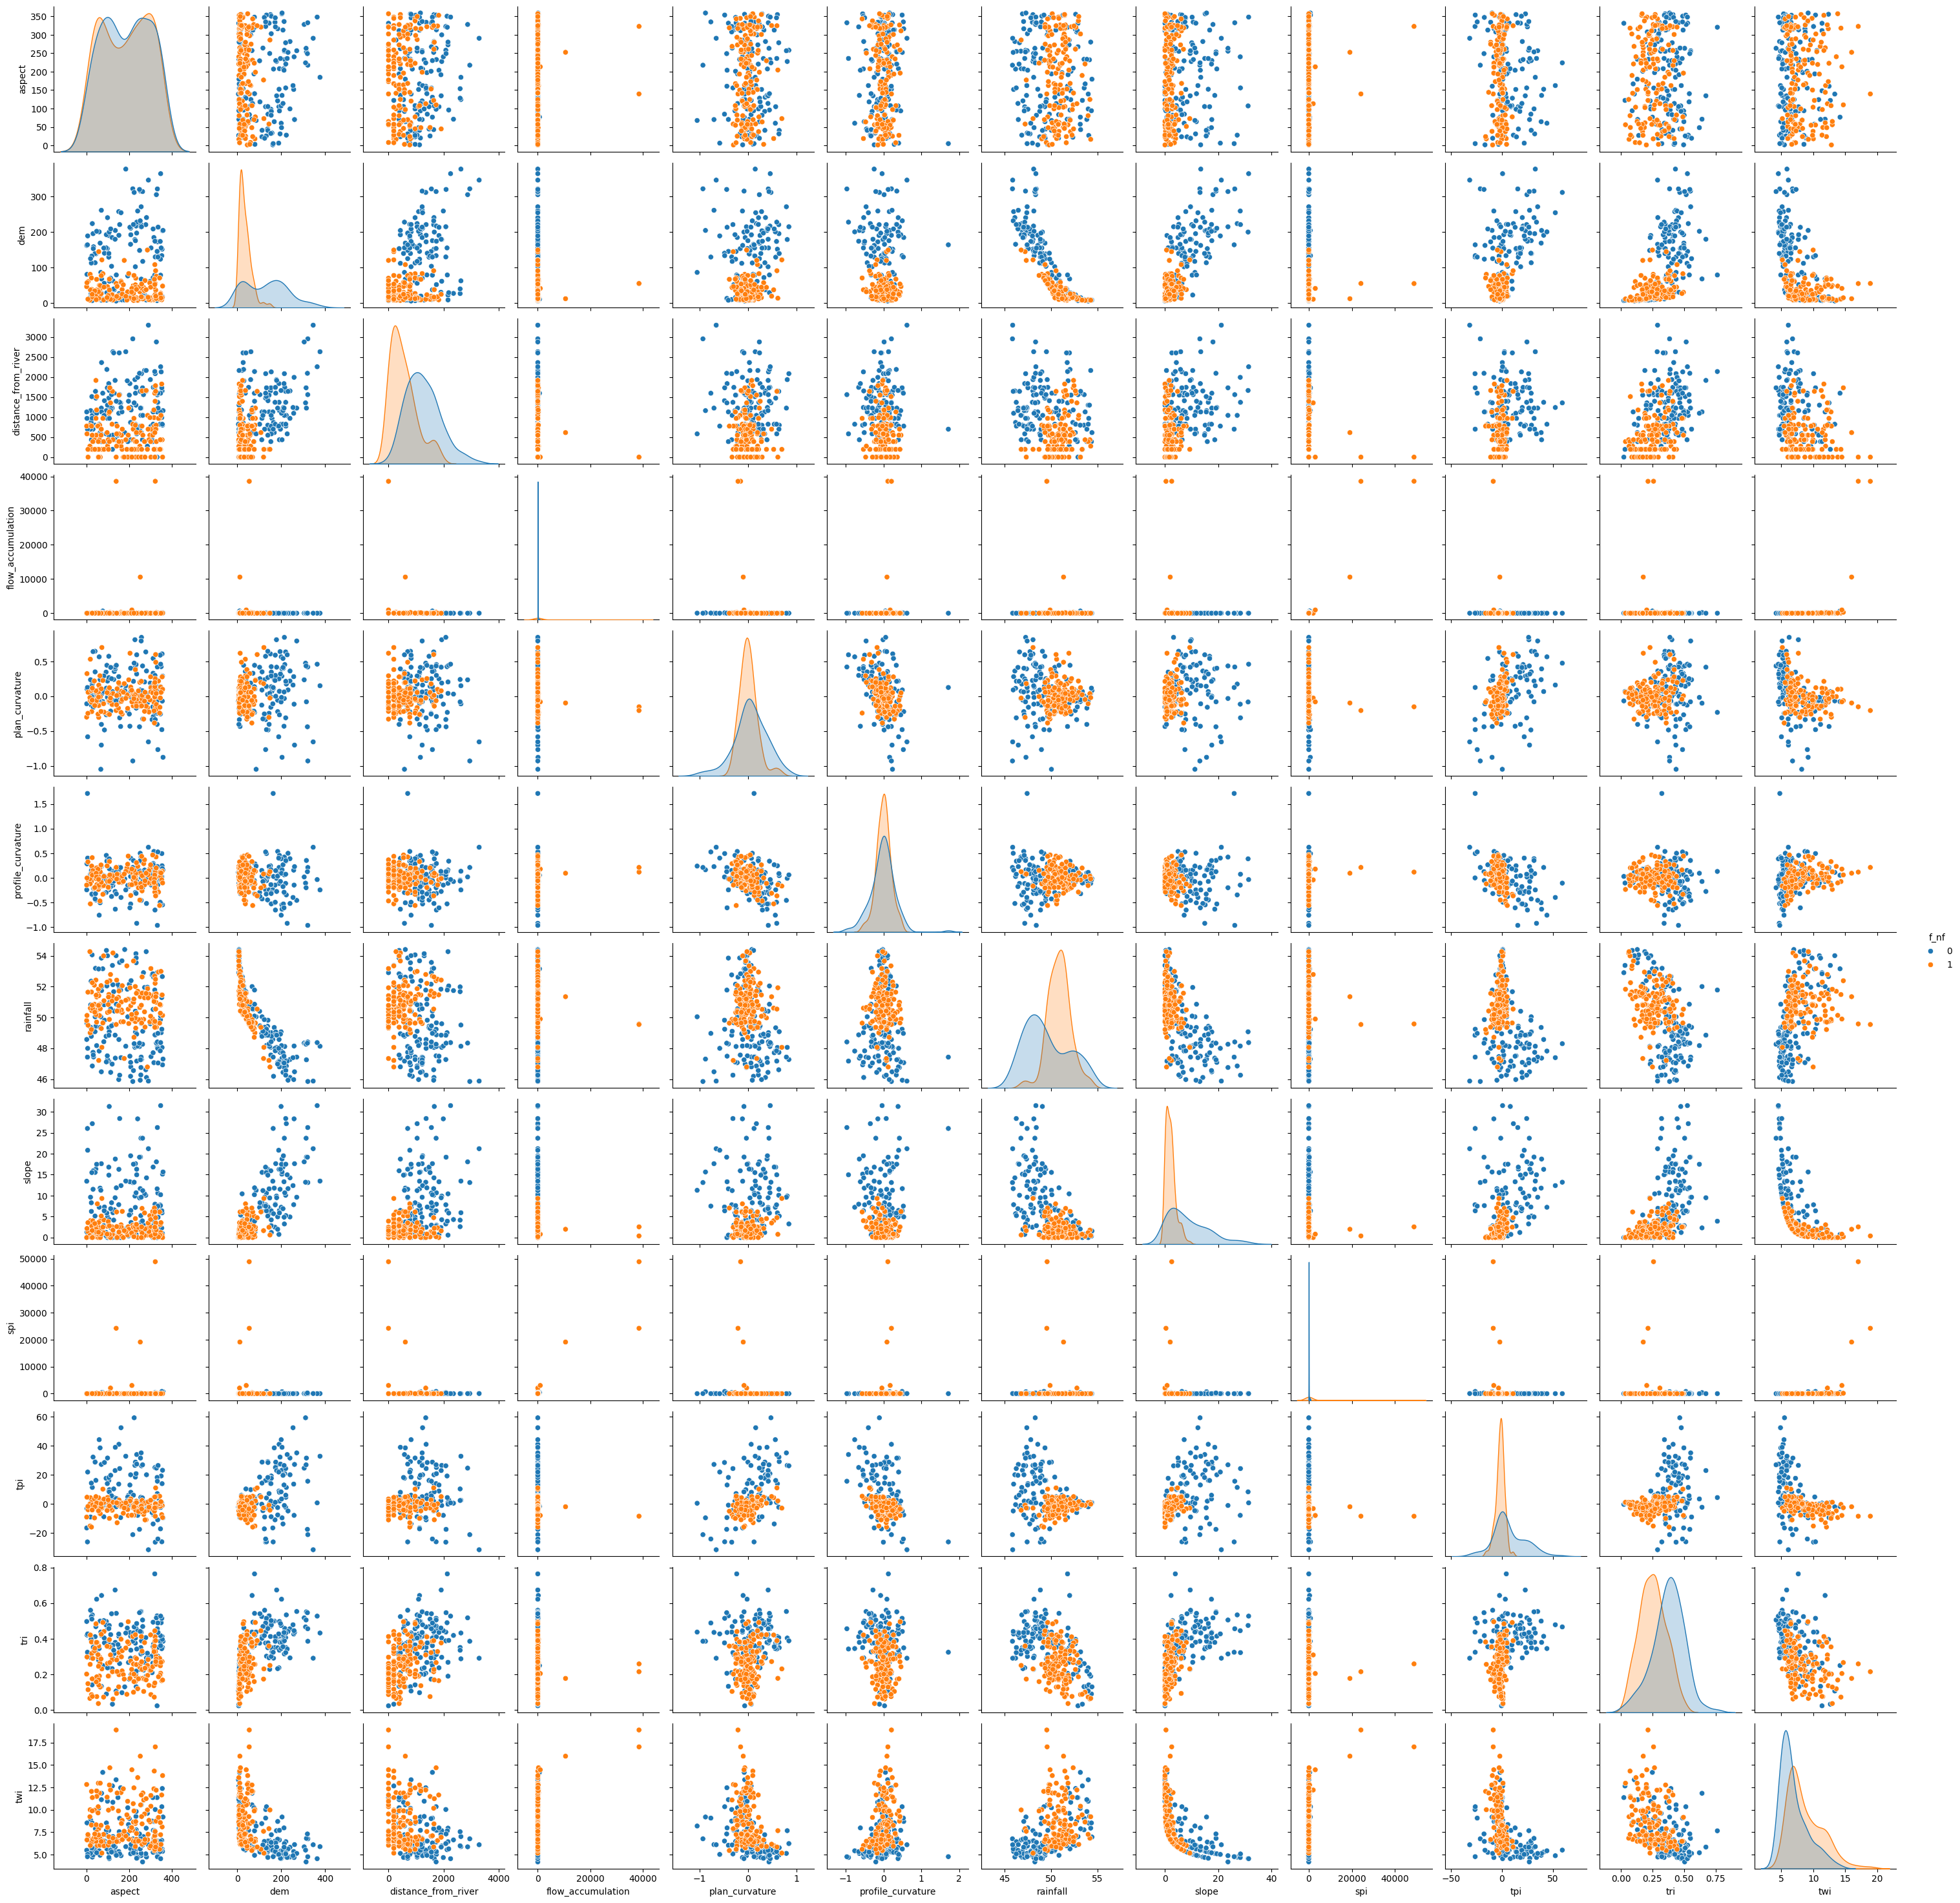

In [ ]:
sns.pairplot(df, hue='f_nf')

### **Analysis**
\


The pairplot provides a grid of scatter plots between feature pairs, color-coded by flood label (`f_nf`), along with histograms on the diagonal.

---
\

####  Notable Patterns Observed:

| Feature Pair                      | Observation |
|----------------------------------|-------------|
| `dem` vs `f_nf`                  | Clear visual separation — flood points tend to cluster at lower elevations. |
| `distance_from_river` vs `f_nf` | Strong gradient — flood points are mostly closer to rivers. |
| `twi` vs `f_nf`                  | Flood points lean toward higher TWI (wetter areas), with decent separation. |
| `tri` vs `f_nf`                  | Non-flood points dominate higher TRI (more rugged); flood-prone areas show lower TRI. |
| `spi` vs `flow_accumulation`     | Almost perfectly collinear — confirms redundancy (ρ = 0.94 in heatmap). |
| `slope` vs `f_nf`                | Steeper slopes are mostly non-flooded — aligns with expectation. |
| `plan_curvature`, `profile_curvature` | No clear distinction — fairly symmetric and centered around zero for both classes. |
| `rainfall` vs `f_nf`             | Slight shift — flood points lean toward slightly higher rainfall but not very separable. |

---
\
###  Summary

- Features with **visually distinguishable class separation**:
  - `dem`, `distance_from_river`, `tri`, `twi`, `slope`
- Features with **overlapping classes (less informative)**:
  - `aspect`, `rainfall`, `curvature` features
- Features with **strong multicollinearity**:
  - `spi` and `flow_accumulation`

\
> These insights reinforce the earlier findings from the correlation matrix and distributions. Consider dimensionality reduction or feature selection to remove redundancy before model training.



## Skewness and Kurtosis

Check for feature normality

In [ ]:
from scipy.stats import skew, kurtosis

for col in num_cols:
    print(f"{col}: Skewness = {skew(df[col]):.2f}, Kurtosis = {kurtosis(df[col]):.2f}")

aspect: Skewness = -0.05, Kurtosis = -1.34
dem: Skewness = 1.23, Kurtosis = 0.67
distance_from_river: Skewness = 0.76, Kurtosis = 0.26
flow_accumulation: Skewness = 11.17, Kurtosis = 125.36
plan_curvature: Skewness = -0.10, Kurtosis = 1.73
profile_curvature: Skewness = 0.49, Kurtosis = 6.50
rainfall: Skewness = -0.12, Kurtosis = -0.60
slope: Skewness = 1.83, Kurtosis = 3.14
spi: Skewness = 11.76, Kurtosis = 149.18
tpi: Skewness = 1.35, Kurtosis = 3.21
tri: Skewness = 0.13, Kurtosis = -0.20
twi: Skewness = 1.18, Kurtosis = 1.20
aspect: Skewness = -0.05, Kurtosis = -1.34
dem: Skewness = 1.23, Kurtosis = 0.67
distance_from_river: Skewness = 0.76, Kurtosis = 0.26
flow_accumulation: Skewness = 11.17, Kurtosis = 125.36
plan_curvature: Skewness = -0.10, Kurtosis = 1.73
profile_curvature: Skewness = 0.49, Kurtosis = 6.50
rainfall: Skewness = -0.12, Kurtosis = -0.60
slope: Skewness = 1.83, Kurtosis = 3.14
spi: Skewness = 11.76, Kurtosis = 149.18
tpi: Skewness = 1.35, Kurtosis = 3.21
tri: Skewne

### **Analysis**

\


Skewness measures distribution symmetry, while kurtosis describes the "tailedness" (outlier-proneness). Ideal values:
- **Skewness ≈ 0** → symmetric
- **Kurtosis ≈ 3** → normal-tailed
- |Skewness| > 1 → high skew
- Kurtosis > 10 → strong outliers

---

####  Feature-wise Analysis

| Feature              | Skewness | Kurtosis | Interpretation |
|----------------------|----------|----------|----------------|
| `aspect`             | -0.05    | -1.34    | Nearly symmetric; thin tails. No transformation needed. |
| `dem`                | 1.23     | 0.67     | Right-skewed; transformation (e.g., log) may help. |
| `distance_from_river`| 0.76     | 0.26     | Mild skew; not urgent to transform. |
| `flow_accumulation`  | **11.17**| **125.36**| Extremely skewed and outlier-prone — needs log transform. |
| `plan_curvature`     | -0.10    | 1.73     | Normal-like distribution; no action needed. |
| `profile_curvature`  | 0.49     | 6.50     | Slightly skewed, moderate outliers. Consider standardization. |
| `rainfall`           | -0.12    | -0.60    | Symmetric and flat; no transformation needed. |
| `slope`              | 1.83     | 3.14     | Right-skewed with heavy tail — log or sqrt transform recommended. |
| `spi`                | **11.76**| **149.18**| Similar to flow_accumulation — must transform (log1p). |
| `tpi`                | 1.35     | 3.21     | Right-skewed, heavy tail; consider log transform. |
| `tri`                | 0.13     | -0.20    | Almost symmetric; no transformation needed. |
| `twi`                | 1.18     | 1.20     | Skewed; transformation may help (log or box-cox). |

---
\
###  Summary

-  **Highly Skewed & Kurtotic** (Needs transformation):
  - `flow_accumulation`, `spi`, `slope`, `tpi`, `twi`, `dem`

-  **Well-behaved (No transformation needed)**:
  - `aspect`, `plan_curvature`, `profile_curvature`, `rainfall`, `tri`

> Apply log1p or other suitable transformations to skewed features to improve model stability and performance.
